# Práctica 2: Propiedades estadísticas del lenguaje y diversidad

## Verificación empírica de la ley de Zipf

Crearemos un lenguaje artificial de la siguiente forma:
+ Definimos un conjunto de "vocales"
+ El complemento serán las "consonantes"
+ Generamos caracteres aleatorios de la siguiente forma:
  + Con probabilidad $.1$ se genera un "espacio en blanco" lo que determina el fin de la palabra
  + En caso que no se genere un espacio en blanco, con probabilidad $.5$ tomamos una muestra aleatoria del conjunto de vocales, y en otro caso del conjunto de consonantes.

In [1]:
from random import Random

In [2]:
from string import ascii_lowercase

In [3]:
rng = Random()

In [4]:
VOC = "gjhwo"
CONS = [x for x in ascii_lowercase if x not in VOC]

def generate_word():
    """
    Generates a pseudo-random word by sampling from vowels and consonants.

    The function constructs a word by repeatedly appending a random character 
    from either a vowel (VOC) or consonant (CONS) collection. The process 
    continues as long as a random roll is greater than 0.1, ensuring the 
    result is at least one character long.

    Returns:
        str: A randomly generated string of characters.
    """
    word = []
    while len(word) == 0:
        while rng.random() > .1:
            if rng.random() > .5:
                word.append(rng.choice(VOC))
            else:
                word.append(rng.choice(CONS))
    
    return "".join(word)


In [5]:
for _ in range(5):
    print(generate_word())

oawto
w
anokjokglooforrvwsqwrqggviewkxigwwghjclfmjkh
nipdkewjxardopierbabponwwjxbfho
wzgcg


Obtenemos un "corpus" sintético generando millones de palabras aleatorias.
Como únicamente nos interesa analizar las frecuencias de las palabras obtenidas, los resultados los recopilamos con un `Counter`.

Utilizaremos `multiprocessing` para usar varios hilos simultáneamente.

In [6]:
import multiprocessing
from collections import Counter
from concurrent.futures import ProcessPoolExecutor


def worker_task(iterations):
    local_counter = Counter()
    for _ in range(iterations):
        local_counter[generate_word()] += 1
    return local_counter

def run_parallel(total_iterations, num_processes):
    chunk_size = total_iterations // num_processes
    
    with ProcessPoolExecutor(max_workers=num_processes) as executor:
        results = executor.map(worker_task, [chunk_size] * num_processes)
    
    final_counter = Counter()
    for res in results:
        final_counter.update(res)
    return final_counter


In [7]:
NUM_TOKENS = 10**6 # Puede ser 10**7 aunque no cambia mucho el resultado
CORES = max(multiprocessing.cpu_count() - 2, 2)
synthetic_corpus_freq = run_parallel(NUM_TOKENS, CORES)

Utilizaremos `linalg.lstsq` de `numpy` para ajustar una función lineal en el plano $\log - \log$ a las frecuencias obtenidas del corpus sintético.

In [8]:
import numpy as np

def prepare_data(counter_obj, top_k):
    data = counter_obj.most_common(top_k)
    
    ranks = np.arange(1, len(data) + 1)
    counts = np.array([item[1] for item in data])
    
    x = np.log(ranks).reshape(-1, 1)
    y = np.log(counts)
    
    return x, y

def fit_linear(counter_obj, top_k):
    x, y = prepare_data(counter_obj, top_k)
    
    X_mat = np.column_stack((x, np.ones(len(x))))

    coeffs, residuals, rank, s = np.linalg.lstsq(X_mat, y, rcond=None)
    
    slope, intercept = coeffs
    return slope, intercept

Dado que los datos son escasos en la parte inicial de la gráfica, tomamos únicamente los primeros 500 tipos para la regresión:

In [9]:
m_synth, b_synth = fit_linear(synthetic_corpus_freq, 500)

Utilizaremos la siguiente función para graficar la distribución de las palabras generadas en escala log-log.

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
sns.set_theme()

In [12]:
def plot_zipf(counter: Counter, m: float, b: float, 
              top_k: int | None = None, 
              title: str = "Análisis de la Ley de Zipf", 
              ax: plt.Axes | None = None):
    """
    Plots the frequency distribution (Zipf's Law) and its linear fit on a log-log scale.

    Args:
        counter (Counter): Object containing the frequencies of the elements.
        m (float): Slope of the linear model (coefficient).
        b (float): Intercept of the linear model.
        top_k (int, optional): Number of most frequent elements to plot.
        title (str): Title of the plot.
        ax (plt.Axes, optional): Matplotlib axis to plot on. 
                                 If None, a new figure is created.

    Returns:
        plt.Axes: The axis object with the generated plot.
    """
    
    data = counter.most_common(top_k) if top_k else counter.most_common()
    df = pd.DataFrame(data, columns=["Palabra", "Frecuencia"])
    df["Rank"] = np.arange(1, len(df) + 1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    sns.lineplot(
        data=df,
        x="Rank",
        y="Frecuencia",
        ax=ax,
        marker='o',
        markersize=3,
        markeredgewidth=0,
    )

    # Plot Regression Line
    # The linear fit was log(y) = m * log(x) + b
    # Therefore: y = exp(b) * x^m
    x_range = df["Rank"].values
    y_fit = np.exp(b) * (x_range ** m)
    
    ax.plot(x_range, y_fit, color='gray', linestyle='--', linewidth=2,
            label=f'Ajuste lineal:\n $y = e^{{{b:.2f}}} \\cdot x^{{{m:.2f}}}$')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Rango (Log)")
    ax.set_ylabel("Frecuencia (Log)")
    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.legend()

    return ax

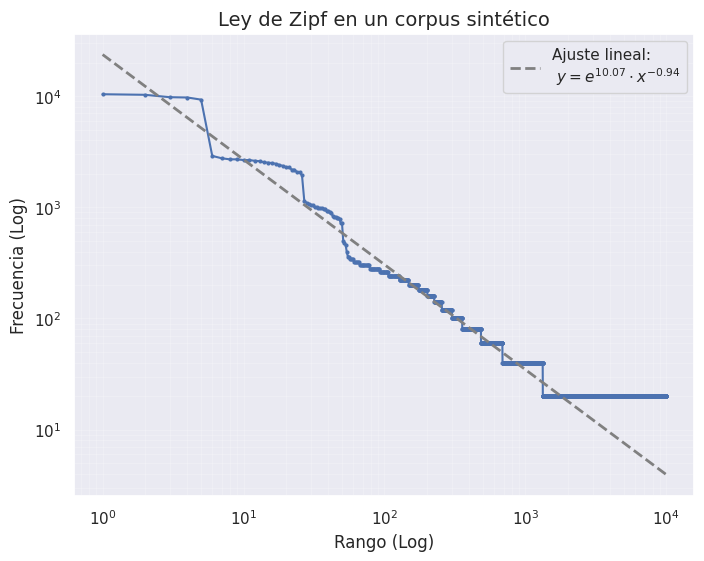

In [13]:
_ = plot_zipf(synthetic_corpus_freq, m_synth, b_synth, 10000, "Ley de Zipf en un corpus sintético")

Compararemos este resultado con los corpus de `elotl`.

In [14]:
!pip install elotl

In [15]:
import elotl.corpus as ec

In [16]:
elotl_corpora = {
    c: ec.load(c) for c in map(lambda x: x[0], ec.list_of_corpus())
}

Mostremos algunas métricas sencillas de los corpus:

In [17]:
import itertools
def get_corpus_size(corpus) -> int:
    return len(corpus)

def get_corpus_tokens(corpus) -> int:
    return sum(len(elem[1].split()) for elem in corpus)

def get_corpus_types(corpus) -> int:
    unique_words = set(itertools.chain.from_iterable(elem[1].split() for elem in corpus))
    return len(unique_words)
    
rows = [
    {
        "corpus": name,
        "size": get_corpus_size(obj),
        "tokens": get_corpus_tokens(obj),
        "types": get_corpus_types(obj),
    }
    for name, obj in elotl_corpora.items()
]

corpora_metrics = pd.DataFrame(rows).set_index("corpus")

In [18]:
corpora_metrics

,size,tokens,types
corpus,,,
axolotl,16111,286901,66378
tsunkua,4963,61760,11608
kolo,1710,11855,4315


In [19]:
def get_corpus_freqs(corpus) -> Counter:
    return Counter(itertools.chain.from_iterable(elem[1].split() for elem in corpus))

In [20]:
corpora = {}
for name, corpus in elotl_corpora.items():
    freqs = get_corpus_freqs(corpus)
    m, b = fit_linear(freqs, 500)
    corpora[f"Corpus {name}"] = (freqs, m, b)

In [21]:
corpora["Corpus sintético"] = (
    synthetic_corpus_freq, *fit_linear(synthetic_corpus_freq, 500)
)

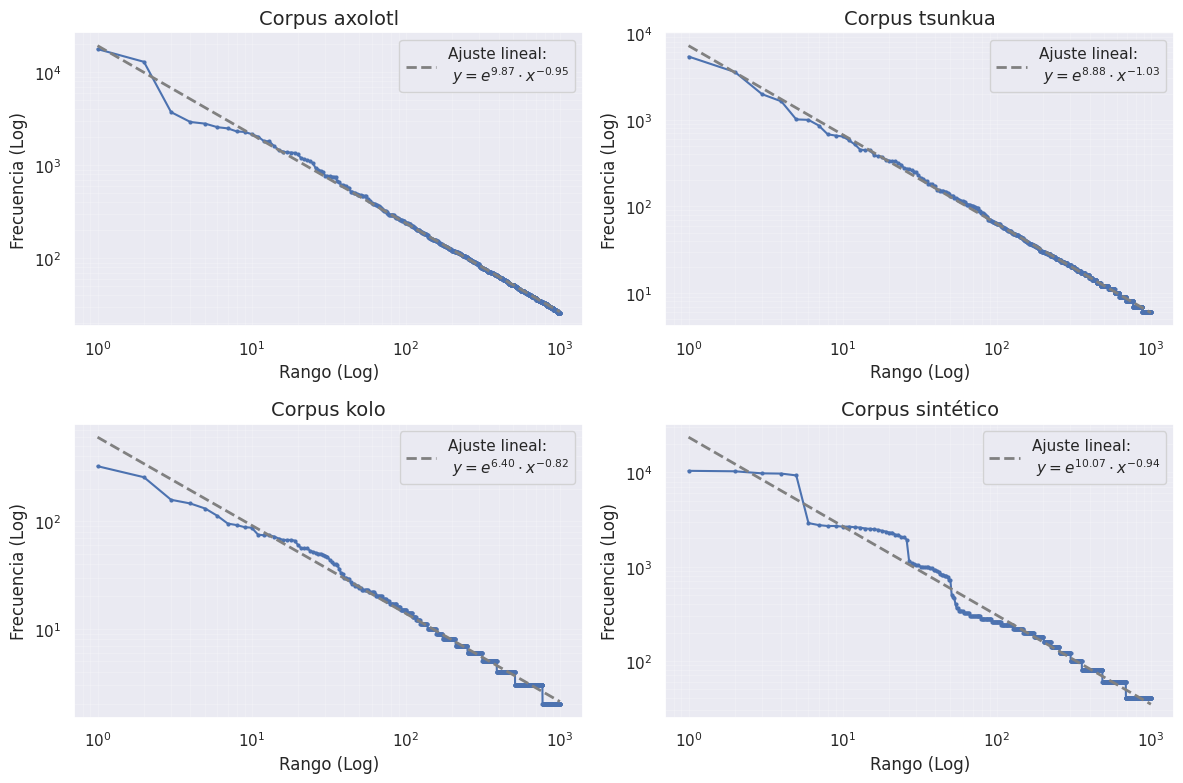

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, (name, (freqs, m, b)) in enumerate(corpora.items()):
    
    plot_zipf(freqs, m, b, top_k=1000, title=name, ax=axes.flatten()[i])

plt.tight_layout()
plt.show()

Podemos ver que aunque todos se pueden ajustar con una línea de pendiente aproximadamente $-1$, en el caso del corpus sintético, el comportamiento en las primeras palabras es atípico, pues presenta una distribución casi uniforme. Esto se debe a que la función que usamos para generar palabras no tiene forma de privilegiar un monograma sobre otro, salvo la distinción entre vocales y consonantes. De igual forma, al menos en principio, la frecuencia de cualquier bigrama solo debería depender en cuántas vocales tiene.

## Diversidad lingüistica de México

Utilizaremos la base de datos de lenguajes de glottolog:

In [23]:
import requests as r

In [24]:
import io
import zipfile

def get_dataframe_from_url(url: str) -> pd.DataFrame:
    """
    Downloads a file from a URL, unzips if necessary, and returns a 
    pandas DataFrame if the content is a CSV.
    """
    response = r.get(url)
    
    if response.status_code != 200:
        raise ConnectionError(f"Failed to download. Status code: {response.status_code}")

    buffer = io.BytesIO(response.content)
    
    if zipfile.is_zipfile(buffer):
        with zipfile.ZipFile(buffer) as z:
            csv_files = [f for f in z.namelist() if f.lower().endswith('.csv')]
            if not csv_files:
                raise ValueError("The zip archive does not contain any CSV files.")
            
            with z.open(csv_files[0]) as csv_file:
                return pd.read_csv(csv_file)
    
    if url.lower().endswith('.csv'):
        buffer.seek(0)
        return pd.read_csv(buffer)
    else:
        raise ValueError("The file is not a zip archive and does not have a .csv extension.")

In [25]:
glottolog_languoid_df = get_dataframe_from_url("https://cdstar.eva.mpg.de//bitstreams/EAEA0-608B-9919-A962-0/glottolog_languoid.csv.zip")

In [26]:
glott_languages = glottolog_languoid_df[glottolog_languoid_df.level == "language"]

In [27]:
glott_languages

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.57210,aiw,NaN,NaN,0,0,0,ET
5,aari1240,book1242,book1242,Aariya,True,language,NaN,NaN,aay,NaN,NaN,0,0,0,IN
6,aasa1238,afro1255,sout3054,Aasax,False,language,-4.00679,36.86480,aas,NaN,NaN,0,0,0,TZ
13,abad1241,aust1307,west2850,Abadi,False,language,-9.03389,146.99200,kbt,NaN,NaN,0,0,0,PG
16,abag1245,nucl1709,unun9976,Abaga,False,language,-6.12028,145.66500,abg,NaN,NaN,0,0,0,PG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27158,zuma1239,afro1255,uncl1546,Zumaya,False,language,10.55798,14.44451,zuy,NaN,NaN,0,0,0,CM
27159,zumb1240,afro1255,nucl1830,Zumbun,False,language,10.82700,9.96830,jmb,NaN,NaN,0,0,0,NG
27165,zuni1245,NaN,NaN,Zuni,False,language,35.00560,-108.78200,zun,NaN,NaN,0,0,0,US
27166,zuoj1238,taik1256,nort3180,Zuojiang Zhuang,False,language,22.40000,106.90000,zzj,NaN,NaN,0,0,0,CN VN


In [28]:
def filter_by_extremal_points(extremal, df):
    lat_min = df["latitude"] >  extremal["meridional"]["lat"]
    lat_max = df["latitude"] <  extremal["septentrional"]["lat"]
    lon_min = df["longitude"] > extremal["occidental"]["lon"]
    lon_max = df["longitude"] < extremal["oriental"]["lon"]
    return df[lat_min & lat_max & lon_min & lon_max]

In [29]:
mexico_extreme_points = {
    "septentrional": {"lat": 32.6333, "lon": -114.7500},
    "occidental": {"lat": 32.5333, "lon": -117.0833},
    "meridional": {"lat": 14.5408, "lon": -92.2167},
    "oriental": {"lat": 21.1333, "lon": -86.7333}
}

In [30]:
glotto_mex = filter_by_extremal_points(mexico_extreme_points, glott_languages)

In [31]:
glotto_mex

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
89,acat1239,otom1299,west2948,Acatepec Me'phaa,False,language,17.10340,-99.06020,tpx,NaN,NaN,0,0,3,MX
101,achi1256,maya1287,quic1275,Achi,False,language,15.07300,-90.35130,acr,NaN,NaN,0,0,0,GT
119,adai1235,NaN,NaN,Adai,False,language,31.63140,-92.00590,xad,NaN,NaN,0,0,0,US
202,afro1254,indo1319,gull1243,Afro-Seminole Creole,False,language,31.78430,-99.29340,afs,NaN,NaN,0,0,0,MX US
254,agua1252,maya1287,ixil1250,Aguacateco,False,language,15.33070,-91.31530,agu,NaN,NaN,0,0,0,GT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26954,zaca1242,otom1299,east2736,Zacatepec Chatino,False,language,16.08000,-97.30690,ctz,NaN,NaN,0,0,0,MX
26997,zani1235,otom1299,papa1270,Zaniza Zapotec,False,language,16.68040,-97.28760,zpw,NaN,NaN,0,0,0,MX
27057,zenz1235,otom1299,core1263,Zenzontepec Chatino,False,language,16.52799,-97.45546,czn,NaN,NaN,0,0,0,MX
27106,zina1239,sign1238,deaf1237,Zinacantec family homesign,False,language,16.75660,-92.71750,NaN,NaN,NaN,0,0,0,MX


In [32]:
import plotly.express as px

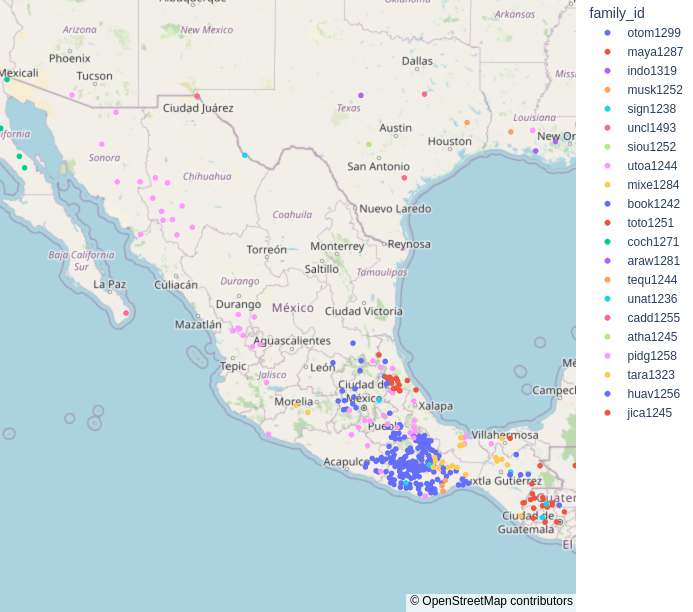

In [33]:
fig = px.scatter_map(
    glotto_mex, 
    lat="latitude", 
    lon="longitude", 
    hover_name="name",
    color="family_id",
    zoom=4,
    center={"lat": 23.6, "lon": -102.5},
    height=600
)

fig.update_layout(map_style="open-street-map", margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [34]:
china_extreme_points = {
    "septentrional": {"lat": 53.5600, "lon": 123.2500},
    "occidental": {"lat": 39.3833, "lon": 73.5000},
    "meridional": {"lat": 18.1500, "lon": 109.5000},
    "oriental": {"lat": 48.3333, "lon": 134.7667}
}

In [35]:
glotto_china = filter_by_extremal_points(china_extreme_points, glott_languages)

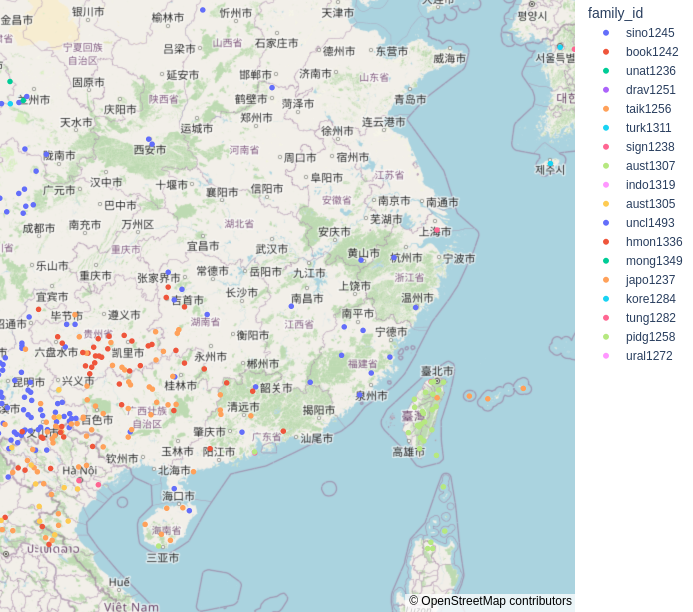

In [36]:
fig = px.scatter_map(
    glotto_china, 
    lat="latitude", 
    lon="longitude", 
    hover_name="name",
    color="family_id",
    zoom=4,
    center={"lat": 28, "lon": 115},
    height=600,
)

fig.update_layout(map_style="open-street-map", margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [37]:
mongolia_extreme_points = {
    "septentrional": {"lat": 52.1500, "lon": 98.9500},
    "occidental": {"lat": 48.8833, "lon": 87.7333},
    "meridional": {"lat": 41.5833, "lon": 105.0000},
    "oriental": {"lat": 46.7167, "lon": 119.9833}
}

In [38]:
glotto_mongolia = filter_by_extremal_points(mongolia_extreme_points, glott_languages)

In [39]:
glotto_mongolia

,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
4282,chin1476,mong1349,buri1258,China Buriat,False,language,48.759300,117.786000,bxu,NaN,NaN,0,0,1,CN MN RU
7866,halh1238,mong1349,mong1331,Halh Mongolian,False,language,48.323970,106.288740,khk,NaN,NaN,0,0,5,MN RU
10455,kham1281,mong1349,oira1260,Khamnigan Mongol,False,language,49.000000,117.000000,ykh,NaN,NaN,0,0,2,CN MN RU
10770,kita1247,mong1349,mong1349,Kitan,False,language,44.377300,115.986000,zkt,NaN,NaN,0,0,0,CN
14469,midd1351,mong1349,mong1329,Middle Mongol,False,language,48.726180,108.674500,xng,NaN,NaN,0,0,0,MN
14889,mong1264,sign1238,nucl1824,Mongolian Sign Language,False,language,48.685200,107.528000,msr,NaN,NaN,0,0,0,MN
14891,mong1330,mong1349,buri1258,Mongolia Buriat,False,language,48.768600,109.005000,bxm,NaN,NaN,0,0,2,CN MN RU
16501,nort2686,turk1311,nort3423,Northern Altai,False,language,50.899800,88.067200,atv,NaN,NaN,0,0,4,RU
18123,oldu1238,turk1311,comm1245,Old Turkic,False,language,42.852778,89.529167,oui,NaN,NaN,0,0,6,CN
18970,peri1253,mong1349,mong1331,Peripheral Mongolian,False,language,42.420800,110.157000,mvf,NaN,NaN,0,0,9,CN MN


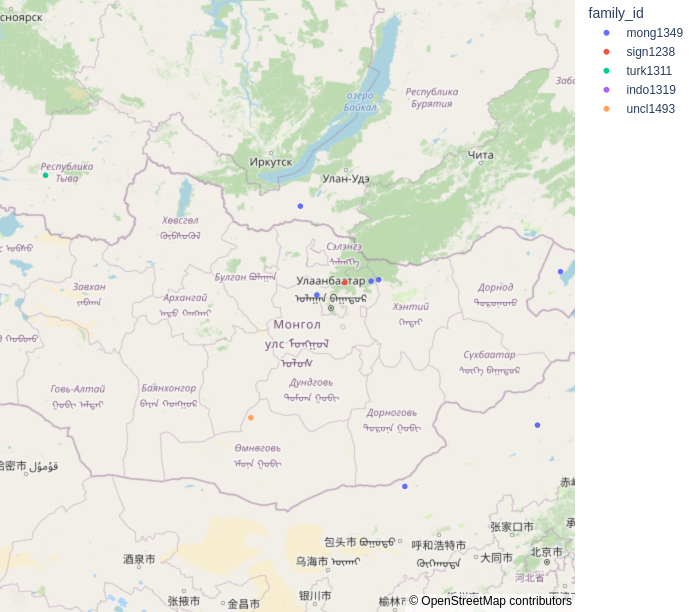

In [40]:
fig = px.scatter_map(
    glotto_mongolia, 
    lat="latitude", 
    lon="longitude", 
    hover_name="name",
    color="family_id",
    zoom=4,
    center={"lat": 48, "lon": 105},
    height=600
)

fig.update_layout(map_style="open-street-map", margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

### ¿Qué tanta diversidad lingüística hay en México con respecto a otras regiones?

En el mapa podemos apreciar una gran cantidad de lenguas, que pertenecen a una variedad de familias. Quizá en diversidad lingüistica México sería comparable a China, una país con aproximadamente 10 veces más población.
En cambio al comparar con Mongolia podemos ver pocas familias lingüisticas y pocos lenguas.
Es por esto que podríamos decir que México tiene una gran diversidad lingüistica.


### ¿Cuál es la zona que dirias que tiene mayor diversidad en México?

La región de Oaxaca presenta una gran densidad de lenguas.